# P2 · Exploratory Data Analysis — Northwind Sales
**Objetivo:** Analizar las ventas del dataset Northwind usando Python.  
Limpiar los datos, explorarlos y visualizar los hallazgos del P1 de forma gráfica.

**Dataset:** Northwind Database — exportado desde MySQL como CSV.  
**Herramientas:** Python · Pandas · Matplotlib · Seaborn

## Fase 1 · Verificación de DataSet

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv(r"H:\Mi unidad\Data Analyst Junior\2. Proyectos\P2-eda-python\data\northwind_sales.csv")
df.head()

,order_id,order_date,product_id,product_name,category,quantity,unit_price,discount,revenue
0,30,2006-01-15 00:00:00,34,Northwind Traders Beer,Beverages,100.0,14.0,0,1400.0
1,30,2006-01-15 00:00:00,80,Northwind Traders Dried Plums,Dried Fruit & Nuts,30.0,3.5,0,105.0
2,31,2006-01-20 00:00:00,7,Northwind Traders Dried Pears,Dried Fruit & Nuts,10.0,30.0,0,300.0
3,31,2006-01-20 00:00:00,51,Northwind Traders Dried Apples,Dried Fruit & Nuts,10.0,53.0,0,530.0
4,31,2006-01-20 00:00:00,80,Northwind Traders Dried Plums,Dried Fruit & Nuts,10.0,3.5,0,35.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      56 non-null     int64  
 1   order_date    56 non-null     object 
 2   product_id    56 non-null     int64  
 3   product_name  56 non-null     object 
 4   category      56 non-null     object 
 5   quantity      56 non-null     float64
 6   unit_price    56 non-null     float64
 7   discount      56 non-null     int64  
 8   revenue       56 non-null     float64
dtypes: float64(3), int64(3), object(3)
memory usage: 4.1+ KB


## Fase 2 · Limpieza de datos
Verificación de nulos, duplicados y corrección de tipos de datos.

In [21]:
# Valores nulos por columna
df.isnull().sum()

order_id        0
order_date      0
product_id      0
product_name    0
category        0
quantity        0
unit_price      0
discount        0
revenue         0
dtype: int64

In [22]:
# Filas duplicadas
df.duplicated().sum()

np.int64(0)

In [23]:
# Corregir tipos de datos
df['order_date'] = pd.to_datetime(df['order_date'])
df['discount'] = df['discount'].astype(float)

# Verificar corrección
df.dtypes

order_id                 int64
order_date      datetime64[ns]
product_id               int64
product_name            object
category                object
quantity               float64
unit_price             float64
discount               float64
revenue                float64
dtype: object

In [24]:
# Validación final — rangos razonables
df.describe()

,order_id,order_date,product_id,quantity,unit_price,discount,revenue
count,56.000000,56,56.000000,56.000000,56.000000,56.0,56.000000
mean,51.339286,2006-04-04 11:52:34.196428544,37.482143,52.535714,22.335179,0.0,1216.732143
min,30.000000,2006-01-15 00:00:00,1.000000,3.000000,2.990000,0.0,35.000000
25%,39.750000,2006-03-23 12:00:00,14.750000,16.500000,9.650000,0.0,215.000000
50%,46.500000,2006-04-05 00:00:00,41.000000,30.000000,18.000000,0.0,510.000000
75%,64.000000,2006-04-26 18:47:56.250000,51.000000,50.000000,35.600000,0.0,1167.000000
max,80.000000,2006-06-23 00:00:00,81.000000,300.000000,81.000000,0.0,13800.000000
std,15.733319,NaN,25.430112,71.227156,16.876204,0.0,2572.676390


## Fase 3 · Visualizaciones

### Gráfico 1 · Ingresos totales por categoría

C:\Users\anher\AppData\Local\Temp\ipykernel_2780\1484209982.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index, palette='Blues_r')


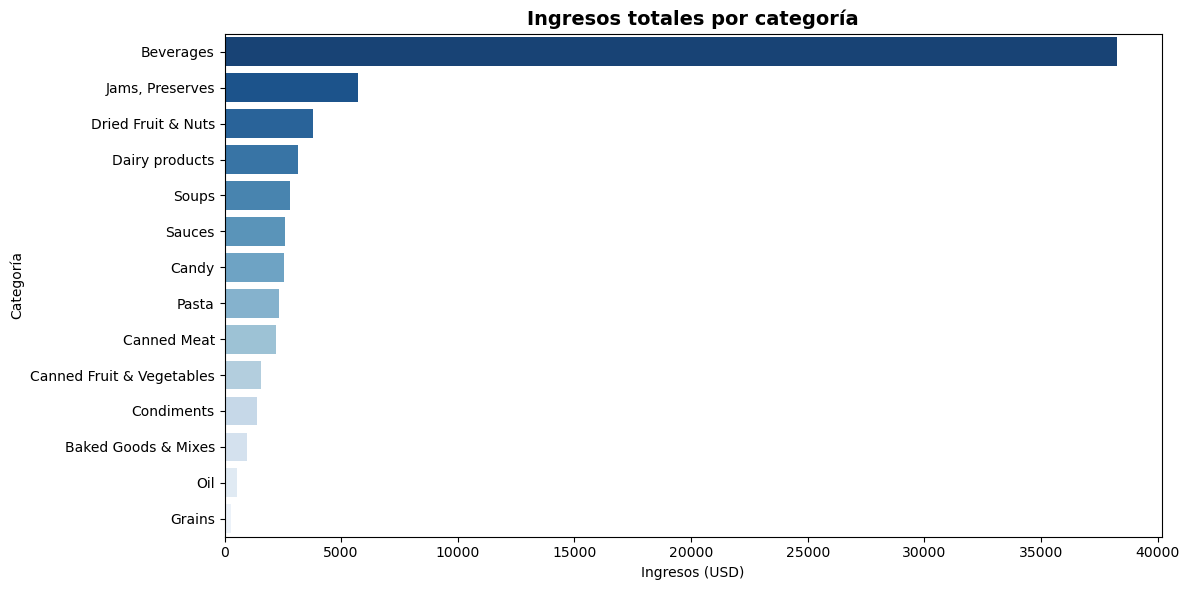

In [25]:
revenue_by_category = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index, palette='Blues_r')

plt.title('Ingresos totales por categoría', fontsize=14, fontweight='bold')
plt.xlabel('Ingresos (USD)')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

**Hallazgo:** Beverages genera ~$38,000 en ingresos, representando más del 55% del total. Las siguientes 3 categorías (Jams & Preserves, Dried Fruit & Nuts, Dairy products) suman en conjunto menos que Beverages sola. Las categorías Grains, Oil y Baked Goods tienen participación mínima.

### Gráfico 2 · Tendencia mensual de ingresos

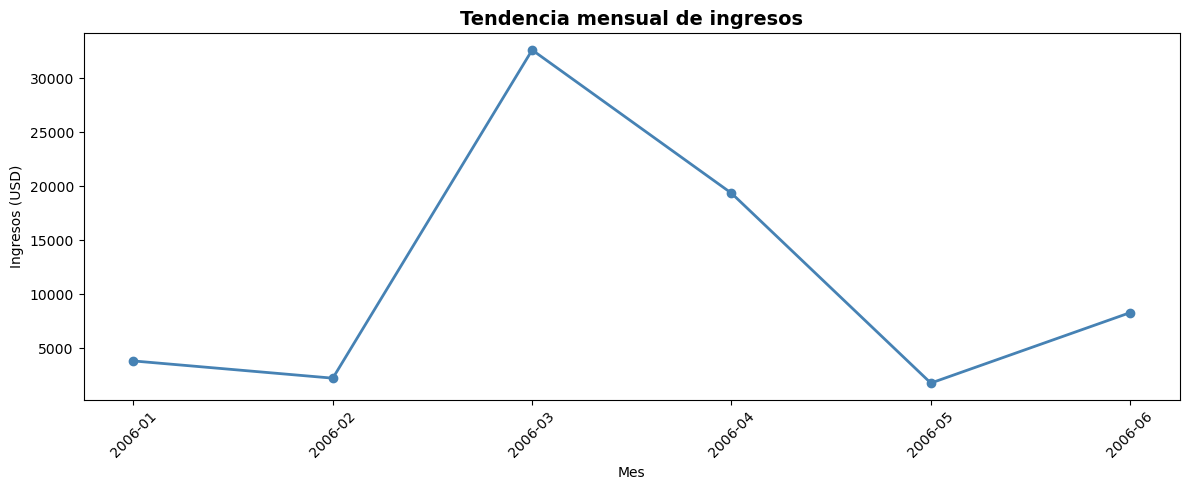

In [26]:
df['month'] = df['order_date'].dt.to_period('M')
monthly_revenue = df.groupby('month')['revenue'].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o', linewidth=2, color='steelblue')

plt.title('Tendencia mensual de ingresos', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Ingresos (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Hallazgo:** Marzo 2006 registra un pico de ~$32,000, más del doble que cualquier otro mes. Enero y Febrero muestran arranque lento. Mayo es el mes más bajo (~$2,500). Junio inicia una recuperación. El pico de marzo será investigado en el análisis de outliers.

### Gráfico 3 · Distribución de precios unitarios por categoría

C:\Users\anher\AppData\Local\Temp\ipykernel_2780\2967099194.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='unit_price', y='category', palette='Blues_r',


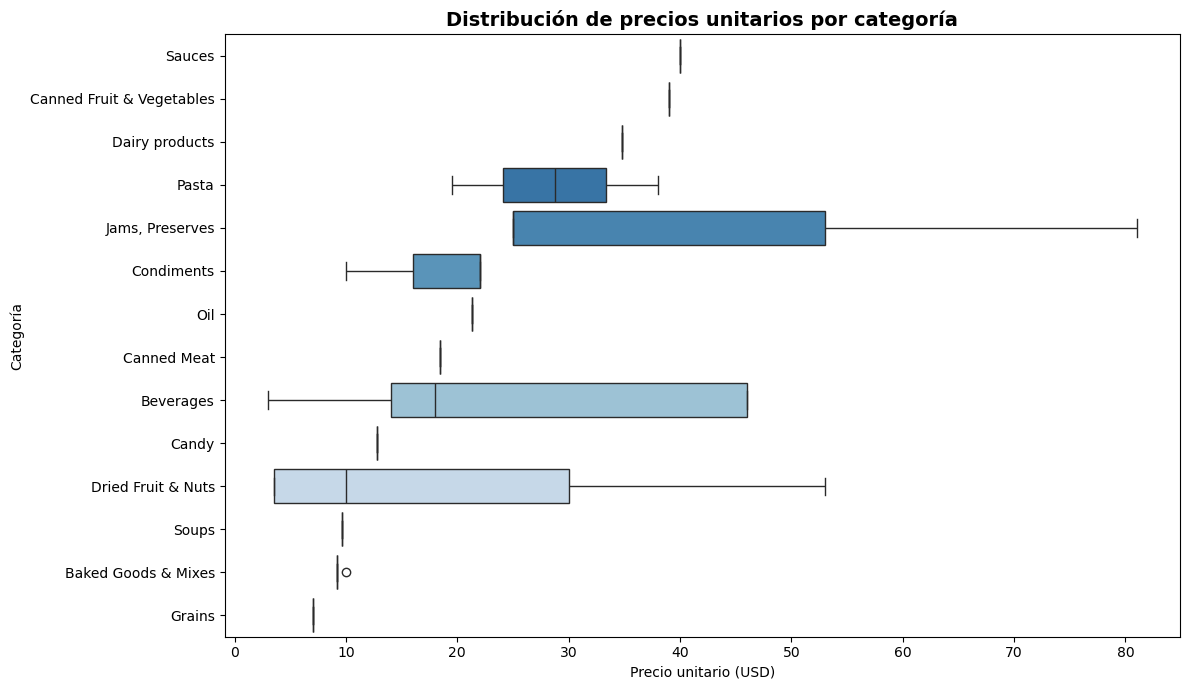

In [27]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='unit_price', y='category', palette='Blues_r',
            order=df.groupby('category')['unit_price'].median().sort_values(ascending=False).index)

plt.title('Distribución de precios unitarios por categoría', fontsize=14, fontweight='bold')
plt.xlabel('Precio unitario (USD)')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

**Hallazgo:** Jams & Preserves y Beverages muestran la mayor variabilidad de precios, lo que indica catálogos mixtos con productos de distintos rangos. Pasta tiene precios consistentes. Baked Goods & Mixes presenta un outlier estadístico en precio unitario que se investigará en la Fase 4.

### Gráfico 4 · Top 10 productos por ingreso

C:\Users\anher\AppData\Local\Temp\ipykernel_2780\1986679406.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='Blues_r')


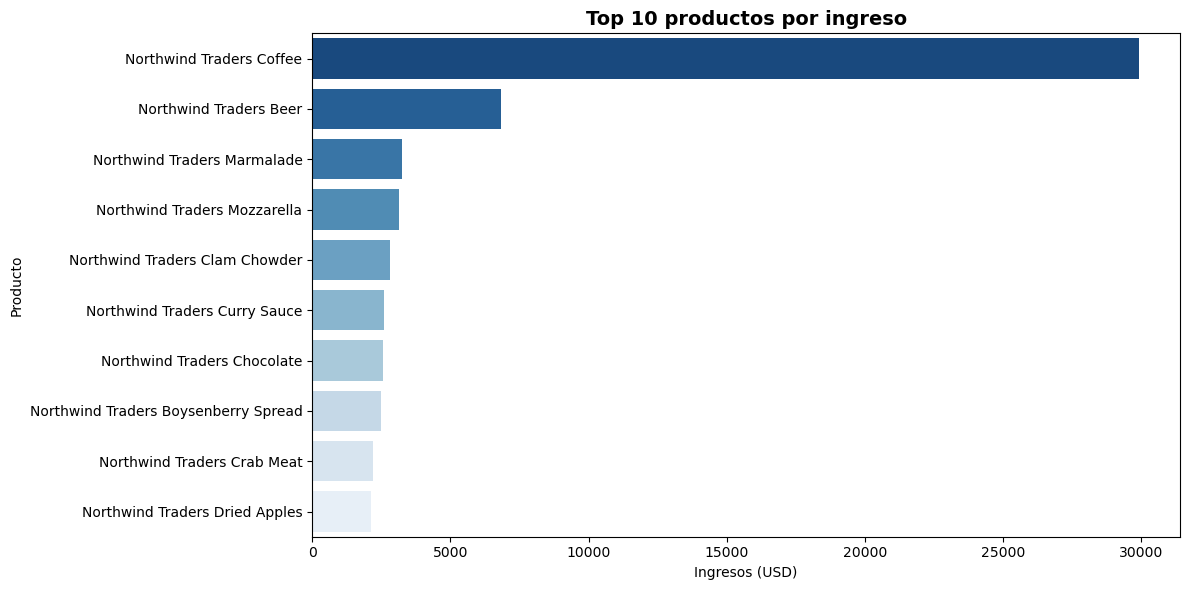

In [28]:
top10 = df.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top10.values, y=top10.index, palette='Blues_r')

plt.title('Top 10 productos por ingreso', fontsize=14, fontweight='bold')
plt.xlabel('Ingresos (USD)')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

**Hallazgo:** Northwind Traders Coffee genera ~$30,000 en ingresos, representando el producto más vendido por amplio margen. Beer es el segundo 
con ~$7,000. Los productos del puesto 3 al 10 están agrupados entre $2,000 y $3,500. Coffee explica tanto el dominio de Beverages en el Gráfico 1 como el pico de marzo en el Gráfico 2.

## Fase 4 · Análisis de outliers
Detección de valores atípicos en quantity y revenue usando el método IQR.

In [29]:
# Método IQR para quantity y revenue
for col in ['quantity', 'revenue']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n--- {col} ---")
    print(f"Límite inferior: {lower:.2f} | Límite superior: {upper:.2f}")
    print(f"Outliers encontrados: {len(outliers)}")
    print(outliers[['order_id', 'order_date', 'product_name', 'category', col]])


--- quantity ---
Límite inferior: -33.75 | Límite superior: 100.25
Outliers encontrados: 5
    order_id order_date                    product_name   category  quantity
10        36 2006-02-23  Northwind Traders Clam Chowder      Soups     200.0
12        38 2006-03-10        Northwind Traders Coffee  Beverages     300.0
14        40 2006-03-24     Northwind Traders Green Tea  Beverages     200.0
15        41 2006-03-24        Northwind Traders Coffee  Beverages     300.0
36        47 2006-04-08          Northwind Traders Beer  Beverages     300.0

--- revenue ---
Límite inferior: -1213.00 | Límite superior: 2595.00
Outliers encontrados: 4
    order_id order_date                 product_name         category  revenue
12        38 2006-03-10     Northwind Traders Coffee        Beverages  13800.0
15        41 2006-03-24     Northwind Traders Coffee        Beverages  13800.0
36        47 2006-04-08       Northwind Traders Beer        Beverages   4200.0
37        58 2006-04-22  Northwind T

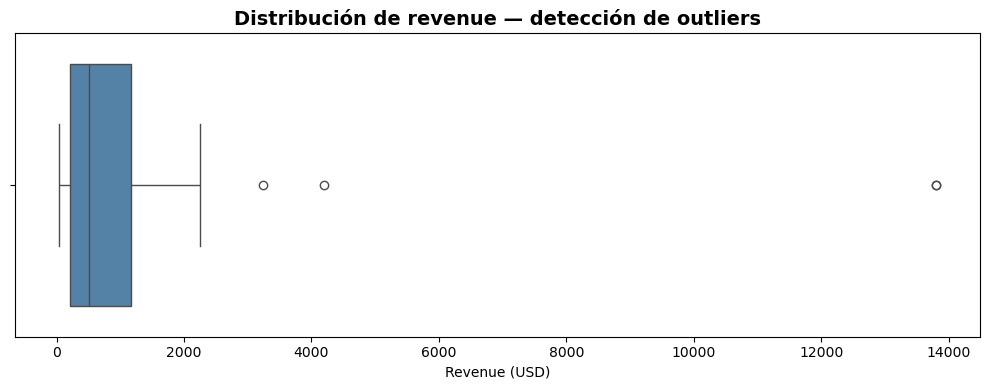

In [30]:
# Visualizar outliers en revenue
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['revenue'], color='steelblue')
plt.title('Distribución de revenue — detección de outliers', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (USD)')
plt.tight_layout()
plt.show()

**Hallazgo:** Se detectaron 5 outliers en quantity (>100 unidades) y 4 en revenue (>$2,595). Todos corresponden a órdenes masivas reales de Beverages, principalmente Northwind Traders Coffee (300 u. × $46 = $13,800 por orden). No son errores de datos — son ventas extraordinarias que explican el pico de marzo 2006 y el dominio de Beverages en ingresos totales. El riesgo de concentración es alto: un solo producto en una sola categoría impulsa desproporcionadamente los resultados globales.